<a href="https://colab.research.google.com/github/matti410/Trading-System-Pipeline-ML/blob/main/TS-Pipeline-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#!pip install -q TA-Lib==0.8.1 vectorbt   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Pipeline-ML')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Pipeline-ML.git

%cd Trading-System-Pipeline-ML

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Pipeline-ML'...
remote: Enumerating objects: 114, done.
remote: Counting objects: 100% (114/114), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 114 (delta 55), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (114/114), 3.35 MiB | 3.93 MiB/s, done.
Resolving deltas: 100% (55/55), done.
/content/Trading-System-Pipeline-ML


In [3]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import sys
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime as dt
"""
from mt5_interaction import start_mt5, set_query_timeframe, retrieve_candlestick_data_range
import pytz
import MetaTrader5 as mt5
"""
import entry_long, entry_short
import engine as eng
from engine.indicatori import aggiungi_indicatori
import engine.event_study
import filter_conditions
from costi_symbol import costi
from diagnostica import sovrapposizioni
from target import costruisci_target
from split import split_train_test, costruisci_X
from modello import rendimenti_trigger, addestra, valuta, importanza
from pesi import pesi_unicita
from oos import indici_oos, valuta_oos
from backtest_oos import trigger_in_fascia, esegui_backtest, tabella_metriche, grafico_equity

print('import ok')

import ok


In [4]:
"""
MT5_username='xxx'
MT5_password='xxx'
MT5_server='ICMarketsEU-Demo'
MT5_path=r"C:\Program Files\MetaTrader 5 IC Markets EU\terminal64.exe"

start_mt5(MT5_username, MT5_password, MT5_server, MT5_path)

start_time_utc = dt.datetime(2020, 1, 1, 23)
fmt = '%Y-%m-%d %H:%M:%S'
tz = pytz.timezone('Europe/Rome')
finish_time_utc = dt.datetime.now() + relativedelta(hours=4)

symbol = "EURUSD"
timeframe = 'M15'
horizon=15

df_raw = retrieve_candlestick_data_range(start_time_utc, finish_time_utc, symbol, timeframe=timeframe, dataframe=True).iloc[:-1]

df_raw.head(3)
"""
from engine.broker_tz_diagnostic import to_utc_index

symbol    = "EURUSD"
timeframe = 'M15'

df_raw = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df_raw = to_utc_index(df_raw, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df_raw):,} barre  ·  da {df_raw.index[0]}  a  {df_raw.index[-1]}")
df_raw.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-18 20:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


### Costi del symbol

Spread, commissione, pip e lotto si leggono da `costi_symbol.py` in base a `symbol` (conto IC Markets EU Standard). Per un nuovo strumento si aggiunge una riga lì, non si tocca il notebook. Se il symbol non è in tabella, la cella si ferma con un messaggio.


In [5]:
COSTI = costi(symbol)
print(f"{symbol}: spread {COSTI['spread_pips']} pips + commissione {COSTI['commissione_pips']} pips "
      f"= {COSTI['costo_pips']} pips a trade  ·  pip {COSTI['pip_size']}  ·  1 lotto = {COSTI['lotto']:,}")

EURUSD: spread 0.8 pips + commissione 0.0 pips = 0.8 pips a trade  ·  pip 0.0001  ·  1 lotto = 100,000


### Features Engineering

In [6]:
df = aggiungi_indicatori(df_raw)

In [7]:
# CONDIZIONI DI INGRESSO LONG/SHORT
df = entry_short.aggiungi_trigger_short(df)
df = entry_long.aggiungi_trigger_long(df)

# CONDIZIONI DI FILTRO
for nome, (funzione, direction, pair) in filter_conditions.FILTRI.items():
    df[nome] = funzione(df)

df.dropna(inplace=True)

# Taglio del riscaldamento: nelle prime barre alcune condizioni valgono False
# solo perche' manca storia (un confronto con NaN da' False, non NaN, quindi
# dropna non le toglie). La finestra piu' lunga del catalogo e' E7 (percentile
# su 2000 barre). Se aggiungi una condizione con finestra piu' lunga, alza questo numero.
RISCALDAMENTO = 2100
df = df.iloc[RISCALDAMENTO:]
print(f"Dopo il riscaldamento: {len(df):,} barre, da {df.index[0]}")
df.tail(5)

Dopo il riscaldamento: 165,023 barre, da 2020-02-03 19:00:00+00:00


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,...,F2_HIGH_VOLATILITY,F3_VOLUME_ABOVE_AVG,F4_TALL_CANDLE,F5_LOW_DRIFT_REGIME,F6_SHORT_TERM_CONSISTENCY,F7_UPTREND_CONTEXT,F8_TREND_CONVICTION_UP,F9_TREND_CONVICTION_DOWN,F10_EXTENDED_UP,F11_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,0,65.639325,0.000440,0.000315,0.000125,...,False,False,False,True,False,True,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,0,64.994395,0.000444,0.000341,0.000103,...,False,False,False,True,False,True,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,...,False,False,False,True,False,True,True,False,False,False
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,...,False,False,False,True,False,True,True,False,False,False
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,...,False,False,False,True,False,True,True,False,False,False


### Andamento del prezzo dopo il trigger

##### IS - OOS Split

In [8]:
df_is = df.iloc[:round(len(df)*0.8)]
df_oos = df.iloc[round(len(df)*0.8):]

### Sovrapposizioni fra condizioni

Controllo da rifare ogni volta che si aggiunge un filtro F* o un trigger E*: mostra le coppie che misurano quasi la stessa cosa. Si calcola solo su `df_is`, perché decidere quali condizioni tenere è una scelta e l'OOS non deve entrarci.

**Come leggere l'output:** `A_dentro_B_%` vicino a 100 = quando scatta A, scatta quasi sempre anche B (A è contenuta in B). `corr` vicino a −1 = una è il contrario esatto dell'altra. Per i trigger `finestra=2` conta come "insieme" anche due trigger a 2 barre di distanza. Vengono stampate solo le coppie sopra `SOGLIA_SOVRAPP`.


In [9]:
SOGLIA_SOVRAPP = 70   # % — sotto questa soglia la coppia non viene stampata

colonne_F = [c for c in df_is.columns if re.match(r'^F\d+_', c)]
colonne_E = [c for c in df_is.columns if re.match(r'^E\d+_', c)]

print("===== FILTRI F* =====")
print(sovrapposizioni(df_is, colonne_F, soglia=SOGLIA_SOVRAPP).to_string())
print("\n===== TRIGGER E* (entro 2 barre) =====")
print(sovrapposizioni(df_is, colonne_E, finestra=2, soglia=SOGLIA_SOVRAPP).to_string())

===== FILTRI F* =====
                     A                   B    n_A    n_B  A_dentro_B_%  B_dentro_A_%  max_dentro_%  corr
0  F3_VOLUME_ABOVE_AVG      F4_TALL_CANDLE  60620  21228         32.24         92.08         92.08  0.41
1         F1_ADX_ABOVE  F2_HIGH_VOLATILITY  81873  32715         31.12         77.88         77.88  0.19
2   F7_UPTREND_CONTEXT     F10_EXTENDED_UP  66347  24820         29.10         77.79         77.79  0.26

===== TRIGGER E* (entro 2 barre) =====
                                A                                  B    n_A   n_B  A_dentro_B_%  B_dentro_A_%  max_dentro_%  corr
0         E10_SHORT_SHOOTING_STAR  E10_SHORT_SHOOTING_STAR_CONFIRMED    469   214         45.63        100.00        100.00 -0.00
1             E11_SHORT_ENGULFING      E11_SHORT_ENGULFING_CONFIRMED  13548  6430         50.13        100.00        100.00 -0.08
2                E12_SHORT_HARAMI         E12_SHORT_HARAMI_CONFIRMED   6631  3218         49.62        100.00        100.00 -0.0

In [10]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 18 entry long registrate (0 gia' presenti).
[registra_trigger_short] 18 entry short registrate (0 gia' presenti).


In [11]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

36 entry · orizzonte 25 barre · 149,356 trigger misurati
soglia di rumore per 36 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.82  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


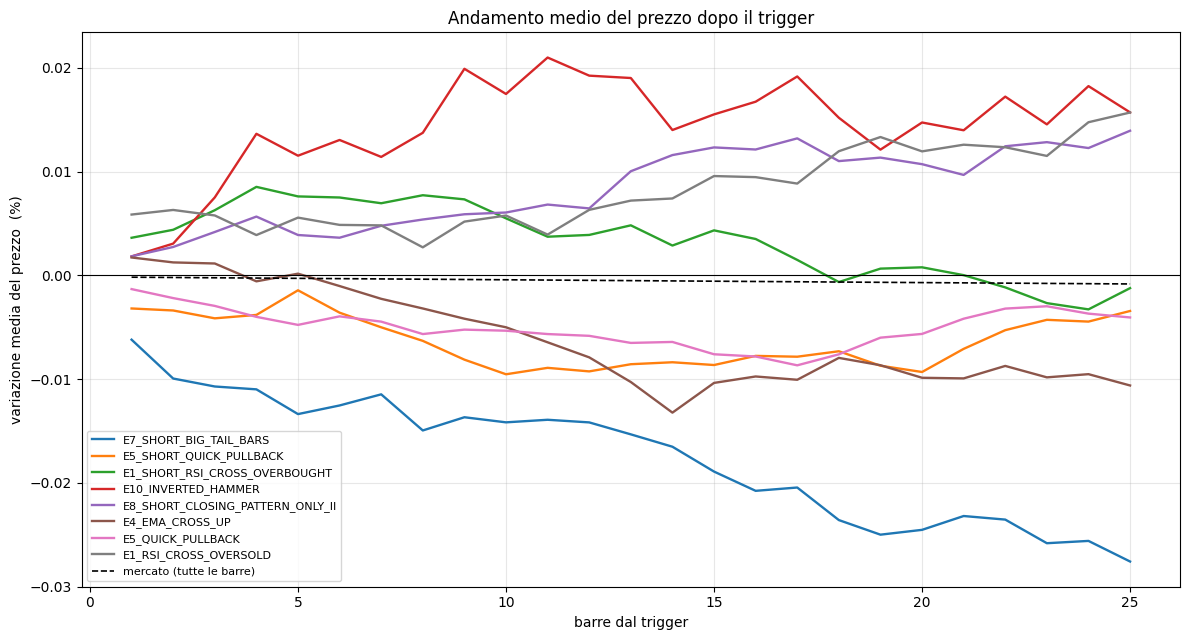

In [12]:
entry_candidate = [n for n in eng.registry.list_entries()]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()

#### LONG side

In [13]:
l1 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
l1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
3,E10_INVERTED_HAMMER,2.313125,0.021008,2.701351,False
7,E1_RSI_CROSS_OVERSOLD,1.732702,0.015706,1.972294,False
18,E7_BIG_TAIL_BARS,1.276890,0.011531,1.288670,False
22,E6_BACK_IN_STYLE,0.860244,0.007782,1.110424,False
28,E10_INVERTED_HAMMER_CONFIRMED,0.809074,0.007339,0.915266,False
11,E3_LONG_INTRABAR_WEAKNESS_FADE,0.649793,0.005877,1.757472,False


In [14]:
l2 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)
l2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
0,E7_SHORT_BIG_TAIL_BARS,-3.047526,-0.027587,-2.987233,False
15,E13_SHORT_EVENING_STAR,-1.655397,-0.015022,-1.471398,False
13,E6_SHORT_BACK_IN_STYLE,-1.486623,-0.013440,-1.650280,False
33,E10_SHORT_SHOOTING_STAR_CONFIRMED,-1.153776,-0.010473,-0.727566,False
1,E5_SHORT_QUICK_PULLBACK,-1.052152,-0.009532,-2.889923,False
25,E10_SHORT_SHOOTING_STAR,-0.833551,-0.007580,-0.981196,False


#### SHORT side

In [15]:
s1 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
s1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
4,E8_SHORT_CLOSING_PATTERN_ONLY_II,1.543825,0.013950,2.258658,False
19,E4_SHORT_EMA_CROSS_DOWN,1.082217,0.009793,1.237565,False
2,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.946055,0.008538,2.783721,False
8,E3_SHORT_INTRABAR_STRENGTH_FADE,0.410163,0.003706,1.870053,False
34,E9_SHORT_HANGING_MAN,0.309685,0.002793,0.633767,False
9,E2_SHORT_ZLEMA_CROSS_DOWN,-0.210925,-0.001906,-1.809164,False


In [16]:
s2 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)

s2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
5,E4_EMA_CROSS_UP,-1.462301,-0.013231,-2.232531,False
35,E13_MORNING_STAR,-1.074913,-0.009789,-0.525162,False
6,E5_QUICK_PULLBACK,-0.958929,-0.008670,-2.015190,False
17,E12_HARAMI_CONFIRMED,-0.553068,-0.004990,-1.315340,False
23,E9_HAMMER,-0.502007,-0.004545,-1.074511,False
24,E14_BELT_HOLD_CONFIRMED,-0.454937,-0.004111,-0.984861,False


### LONG Dataframe

In [17]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_long_selected_feat  = l1.iloc[:2,0].to_list() + s1.iloc[:2,0].to_list()

df_LONG = df[colonne_ohlcv + entry_long_selected_feat + colonne_eventi]
df_LONG

,Open,High,Low,Close,Volume,E10_INVERTED_HAMMER,E1_RSI_CROSS_OVERSOLD,E8_SHORT_CLOSING_PATTERN_ONLY_II,E4_SHORT_EMA_CROSS_DOWN,F1_ADX_ABOVE,...,F2_HIGH_VOLATILITY,F3_VOLUME_ABOVE_AVG,F4_TALL_CANDLE,F5_LOW_DRIFT_REGIME,F6_SHORT_TERM_CONSISTENCY,F7_UPTREND_CONTEXT,F8_TREND_CONVICTION_UP,F9_TREND_CONVICTION_DOWN,F10_EXTENDED_UP,F11_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,False,False,False,False,True,True,True,False,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,False,False,False,True,False,True,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,False,False,False,True,False,True,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,False,False,False,True,False,True,True,False,False,False


#### SHORT Dataframe

In [18]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_short_selected_feat = l2.iloc[:2,0].to_list() + s2.iloc[:2,0].to_list()

df_SHORT = df[colonne_ohlcv + entry_short_selected_feat + colonne_eventi]
df_SHORT

,Open,High,Low,Close,Volume,E7_SHORT_BIG_TAIL_BARS,E13_SHORT_EVENING_STAR,E4_EMA_CROSS_UP,E13_MORNING_STAR,F1_ADX_ABOVE,...,F2_HIGH_VOLATILITY,F3_VOLUME_ABOVE_AVG,F4_TALL_CANDLE,F5_LOW_DRIFT_REGIME,F6_SHORT_TERM_CONSISTENCY,F7_UPTREND_CONTEXT,F8_TREND_CONVICTION_UP,F9_TREND_CONVICTION_DOWN,F10_EXTENDED_UP,F11_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,False,False,False,False,True,True,True,False,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,False,False,False,True,False,True,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,False,False,False,True,False,True,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,False,False,False,True,False,True,True,False,False,False


### Costruzione TARGET (LONG / SHORT)

Per ogni trigger calcola l'esito reale: ingresso all'Open della barra successiva, uscita al Close dopo H barre (stesso orizzonte dell'event study). TARGET=1 se il rendimento supera il costo del trade (spread + commissione del symbol, da `COSTI`), 0 altrimenti. Righe senza trigger non compaiono — il modello vedrà solo occorrenze reali, mai "rumore".

**Come leggere l'output:** il numero di righe è quanti trigger sono utilizzabili per l'addestramento di ciascun lato; la % di classe 1 dice quanto è bilanciato il problema. Se una delle due % è vicina a 0% o 100%, il modello non ha nulla da imparare — fermati e segnalamelo prima di proseguire.

**Prossimo passo:** se i numeri sono ragionevoli, procediamo con lo split IS/OOS + embargo sui due target.

In [19]:
TARGET_LONG = costruisci_target(df_LONG, entry_long_selected_feat, direction=1, horizon=H,
                                costo_pips=COSTI["costo_pips"], pip_size=COSTI["pip_size"])
TARGET_SHORT = costruisci_target(df_SHORT, entry_short_selected_feat, direction=-1, horizon=H,
                                 costo_pips=COSTI["costo_pips"], pip_size=COSTI["pip_size"])

print("LONG  — righe:", len(TARGET_LONG), " classe 1:", f"{TARGET_LONG.mean():.1%}")
print("SHORT — righe:", len(TARGET_SHORT), " classe 1:", f"{TARGET_SHORT.mean():.1%}")

LONG  — righe: 6790  classe 1: 48.2%
SHORT — righe: 3368  classe 1: 47.3%


### Split train/test e matrice X

Divide i trigger di df_is in train (80%, il passato) e test (20%, il periodo successivo). Toglie i trigger vicini ai confini la cui etichetta userebbe prezzi del test o dell'OOS. df_oos resta intatto.

**Come leggere l'output:** righe e % di classe 1 di train e test per ciascun lato; la % dovrebbe restare simile fra train e test. X deve avere 24 colonne (4 trigger + 20 contesto).


In [20]:
print("===== LONG =====")
idx_train_L, idx_test_L = split_train_test(TARGET_LONG, df_is, horizon=H, quota=0.8)
X_LONG = costruisci_X(df_LONG, TARGET_LONG, entry_long_selected_feat)

print("\n===== SHORT =====")
idx_train_S, idx_test_S = split_train_test(TARGET_SHORT, df_is, horizon=H, quota=0.8)
X_SHORT = costruisci_X(df_SHORT, TARGET_SHORT, entry_short_selected_feat)

===== LONG =====
confine train/test: 2024-04-30 22:30:00+00:00  (barra 105614 di 132018)
  trigger in OOS (non usati):       1325
  tolti dal purge (uscita in OOS):  2
  tolti dall'embargo (train->test): 1
  TRAIN:  4428 righe, classe 1 47.8%  (2020-02-04 -> 2024-04-30)
  TEST:   1034 righe, classe 1 48.5%  (2024-05-01 -> 2025-05-22)
X: 6790 righe x 16 colonne (4 trigger E* + 12 contesto F*)

===== SHORT =====
confine train/test: 2024-04-30 22:30:00+00:00  (barra 105614 di 132018)
  trigger in OOS (non usati):       663
  tolti dal purge (uscita in OOS):  0
  tolti dall'embargo (train->test): 0
  TRAIN:  2166 righe, classe 1 47.2%  (2020-02-04 -> 2024-04-30)
  TEST:    539 righe, classe 1 44.9%  (2024-05-01 -> 2025-05-22)
X: 3368 righe x 16 colonne (4 trigger E* + 12 contesto F*)


### Primo modello (LightGBM base, senza pesi) e valutazione

Addestra un modello per lato sul solo train e lo valuta sul test. Impostazioni prudenti, non ottimizzate: è la base di riferimento.

**Come leggere l'output:**
- **AUC**: 0,5 = ordine casuale. Se il train è molto sopra il test, il modello ha imparato regole valide solo sul train.
- **prob. train / test**: quanto sono larghe le probabilità. Se train e test sono molto diversi, qualcosa è cambiato fra i due periodi.
- **Tabella per fasce**: i trigger del test sono ordinati per probabilità e divisi in 5 gruppi uguali (1 = più bassa, 5 = più alta). Se vincenti % e bp crescono dalla 1 alla 5, l'ordine del modello contiene informazione. La riga "tutti" è il risultato senza modello. I bp sono lordi.
- **Feature più usate**: dove il modello cerca informazione.

#### LONG Side

In [21]:
REND_LONG = rendimenti_trigger(df_LONG, TARGET_LONG.index, direction=1, horizon=H)
modello_LONG = addestra(X_LONG, TARGET_LONG, idx_train_L, idx_test_L)

print("===== LONG =====")
fasce_LONG = valuta(modello_LONG, X_LONG, TARGET_LONG, REND_LONG, idx_train_L, idx_test_L)
print(fasce_LONG)
print("\nfeature piu' usate:")
print(importanza(modello_LONG, X_LONG).head(10))

===== LONG =====
AUC   train 0.600   test 0.515   (0.5 = ordine casuale)
prob. train: min 0.245  p10 0.403  p50 0.483  p90 0.548  max 0.769
prob. test:  min 0.271  p10 0.402  p50 0.483  p90 0.549  max 0.712
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.271   0.429    207        44.4          -1.38
2         0.430   0.466    207        49.3           0.04
3         0.466   0.498    206        48.5          -0.08
4         0.498   0.522    207        48.8          -0.87
5         0.522   0.712    207        51.2           1.05
tutti     0.271   0.712   1034        48.5          -0.25

feature piu' usate:
F4_TALL_CANDLE               15.5
F8_TREND_CONVICTION_UP       10.2
F1_ADX_ABOVE                  9.0
F9_TREND_CONVICTION_DOWN      8.6
F7_UPTREND_CONTEXT            8.4
E4_SHORT_EMA_CROSS_DOWN       7.5
E1_RSI_CROSS_OVERSOLD         6.2
F6_SHORT_TERM_CONSISTENCY     6.2
F3_VOLUME_ABOVE_AVG           4.9
F1

#### SHORT Side

In [22]:
REND_SHORT = rendimenti_trigger(df_SHORT, TARGET_SHORT.index, direction=-1, horizon=H)
modello_SHORT = addestra(X_SHORT, TARGET_SHORT, idx_train_S, idx_test_S)

print("===== SHORT =====")
fasce_SHORT = valuta(modello_SHORT, X_SHORT, TARGET_SHORT, REND_SHORT, idx_train_S, idx_test_S)
print(fasce_SHORT)
print("\nfeature piu' usate:")
print(importanza(modello_SHORT, X_SHORT).head(10))

===== SHORT =====
AUC   train 0.640   test 0.500   (0.5 = ordine casuale)
prob. train: min 0.212  p10 0.352  p50 0.472  p90 0.579  max 0.751
prob. test:  min 0.213  p10 0.359  p50 0.465  p90 0.568  max 0.751
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.213   0.389    108        43.5          -5.74
2         0.389   0.446    108        46.3           1.24
3         0.446   0.485    107        44.9           0.89
4         0.485   0.535    108        45.4          -0.01
5         0.535   0.751    108        44.4          -1.09
tutti     0.213   0.751    539        44.9          -0.95

feature piu' usate:
F8_TREND_CONVICTION_UP       20.0
F5_LOW_DRIFT_REGIME          10.1
F2_LOW_VOLATILITY             8.7
F1_ADX_ABOVE                  7.7
F4_TALL_CANDLE                7.4
F3_VOLUME_ABOVE_AVG           7.3
F2_HIGH_VOLATILITY            7.0
F9_TREND_CONVICTION_DOWN      6.5
E7_SHORT_BIG_TAIL_BARS        5.7
F

### Stesso modello con i pesi di unicità

I trigger ammassati (finestre di 25 barre sovrapposte) contano meno nell'addestramento: 5 trigger sulla stessa finestra valgono insieme circa quanto uno isolato. I pesi si calcolano solo sul train. La valutazione sul test è identica alla cella precedente.

**Come leggere l'output:** confronta AUC e tabella per fasce con quelli senza pesi. I pesi si tengono solo se migliorano il test.

In [23]:
PESI_LONG = pesi_unicita(idx_train_L, df_LONG, horizon=H)
modello_LONG_p = addestra(X_LONG, TARGET_LONG, idx_train_L, idx_test_L, pesi=PESI_LONG)
print("===== LONG con pesi =====")
print(f"pesi train: min {PESI_LONG.min():.2f}  mediana {PESI_LONG.median():.2f}  max {PESI_LONG.max():.2f}")
fasce_LONG_p = valuta(modello_LONG_p, X_LONG, TARGET_LONG, REND_LONG, idx_train_L, idx_test_L)
print(fasce_LONG_p)

PESI_SHORT = pesi_unicita(idx_train_S, df_SHORT, horizon=H)
modello_SHORT_p = addestra(X_SHORT, TARGET_SHORT, idx_train_S, idx_test_S, pesi=PESI_SHORT)
print("\n===== SHORT con pesi =====")
print(f"pesi train: min {PESI_SHORT.min():.2f}  mediana {PESI_SHORT.median():.2f}  max {PESI_SHORT.max():.2f}")
fasce_SHORT_p = valuta(modello_SHORT_p, X_SHORT, TARGET_SHORT, REND_SHORT, idx_train_S, idx_test_S)
print(fasce_SHORT_p)

===== LONG con pesi =====
pesi train: min 0.31  mediana 0.93  max 1.65
AUC   train 0.593   test 0.511   (0.5 = ordine casuale)
prob. train: min 0.276  p10 0.431  p50 0.514  p90 0.578  max 0.774
prob. test:  min 0.296  p10 0.430  p50 0.508  p90 0.578  max 0.758
        prob_da  prob_a  trade  vincenti_%  bp_medi_lordi
fascia                                                   
1         0.296   0.452    207        48.3           0.03
2         0.452   0.489    207        47.8          -1.24
3         0.489   0.525    206        46.6           0.70
4         0.525   0.558    207        47.8          -0.70
5         0.558   0.758    207        51.7          -0.02
tutti     0.296   0.758   1034        48.5          -0.25

===== SHORT con pesi =====
pesi train: min 0.34  mediana 1.10  max 1.24
AUC   train 0.644   test 0.485   (0.5 = ordine casuale)
prob. train: min 0.159  p10 0.369  p50 0.477  p90 0.583  max 0.771
prob. test:  min 0.171  p10 0.363  p50 0.471  p90 0.572  max 0.771
        prob

### OOS — soglia fissata sul test, applicata tale e quale

Il modello è quello con i pesi, addestrato solo sul train. La soglia di probabilità è il limite inferiore della fascia scelta, calcolato solo sul test di df_is, e sull'OOS non si ricalcola niente.

FASCE_OPERATIVE = 5 prende il 20% più alto; (4, 5) prende il 40% più alto.

**Come leggere l'output:**
- **prob. test / OOS**: se le due distribuzioni sono simili, la soglia prende nell'OOS una quota simile a quella del test (~20% per la fascia 5).
- **tabella**: confronta "selezionati" con "tutti" nello stesso periodo. I bp sono lordi.

In [24]:
FASCE_OPERATIVE = 5          # oppure un intervallo, es. (4, 5)

idx_oos_L = indici_oos(TARGET_LONG, df_is)
print("===== LONG · OOS =====")
oos_LONG = valuta_oos(modello_LONG_p, X_LONG, TARGET_LONG, REND_LONG,
                      idx_test_L, idx_oos_L, fasce=FASCE_OPERATIVE)
print(oos_LONG)

idx_oos_S = indici_oos(TARGET_SHORT, df_is)
print("\n===== SHORT · OOS =====")
oos_SHORT = valuta_oos(modello_SHORT_p, X_SHORT, TARGET_SHORT, REND_SHORT,
                       idx_test_S, idx_oos_S, fasce=FASCE_OPERATIVE)
print(oos_SHORT)

===== LONG · OOS =====
fascia 5 di 5: soglia prob. da 0.558 a inf  (ricavata solo dal test)
prob. test: min 0.296  p10 0.430  p50 0.508  p90 0.578  max 0.758
prob. OOS : min 0.310  p10 0.434  p50 0.508  p90 0.578  max 0.742
OOS: 2025-05-25 22:15:00+00:00 -> 2026-09-18 11:15:00+00:00
               trade  presi_%  vincenti_%  bp_medi_lordi
                                                        
test fascia 5    210     20.3        51.4          -0.11
test tutti      1034    100.0        48.5          -0.25
OOS fascia 5     306     23.1        53.9           2.20
OOS tutti       1325    100.0        49.0           0.83

===== SHORT · OOS =====
fascia 5 di 5: soglia prob. da 0.527 a inf  (ricavata solo dal test)
prob. test: min 0.171  p10 0.363  p50 0.471  p90 0.572  max 0.771
prob. OOS : min 0.207  p10 0.378  p50 0.476  p90 0.571  max 0.733
OOS: 2025-05-23 01:30:00+00:00 -> 2026-09-18 01:30:00+00:00
               trade  presi_%  vincenti_%  bp_medi_lordi
                               

### Backtest OOS (VectorBT)

Stesse regole del target:
- ingresso all'Open della barra successiva al trigger, uscita al Close a 25 barre, niente SL/TP;
- un trade alla volta per lato: i trigger che scattano con una posizione aperta si saltano (colonna "saltati");
- lotto fisso (1 lotto del symbol, da `COSTI`), spread e commissione inclusi come costo fisso per trade (da `COSTI`).

"tutti i trigger" = stesse regole senza modello, nello stesso periodo. VectorBT non gestisce il margine: il capitale deve coprire il controvalore di 1 lotto.

**Come leggere l'output:** confronta la riga del modello con "tutti i trigger" per ogni lato. Nel grafico, linea blu = modello, grigia = tutti. PnL nella valuta di quotazione (USD su EURUSD).

                               trade  saltati  vincenti_%  trade_medio_bp  \
lato      scenario                                                          
LONG      modello (fascia 5)   223.0     83.0       53.81            0.79   
SHORT     modello (fascia 5)   129.0     12.0       51.94           -0.55   
COMBINATO modello (fascia 5)   352.0     95.0       53.12            0.30   
LONG      tutti i trigger      653.0    672.0       46.40           -0.47   
SHORT     tutti i trigger      455.0    208.0       49.89           -1.13   
COMBINATO tutti i trigger     1108.0    880.0       47.83           -0.74   

                              profit_factor  pnl_totale  rendimento_%  \
lato      scenario                                                      
LONG      modello (fascia 5)           1.12      2003.0          1.34   
SHORT     modello (fascia 5)           0.93      -800.0         -0.53   
COMBINATO modello (fascia 5)           1.04      1203.0          0.80   
LONG      tutti i 

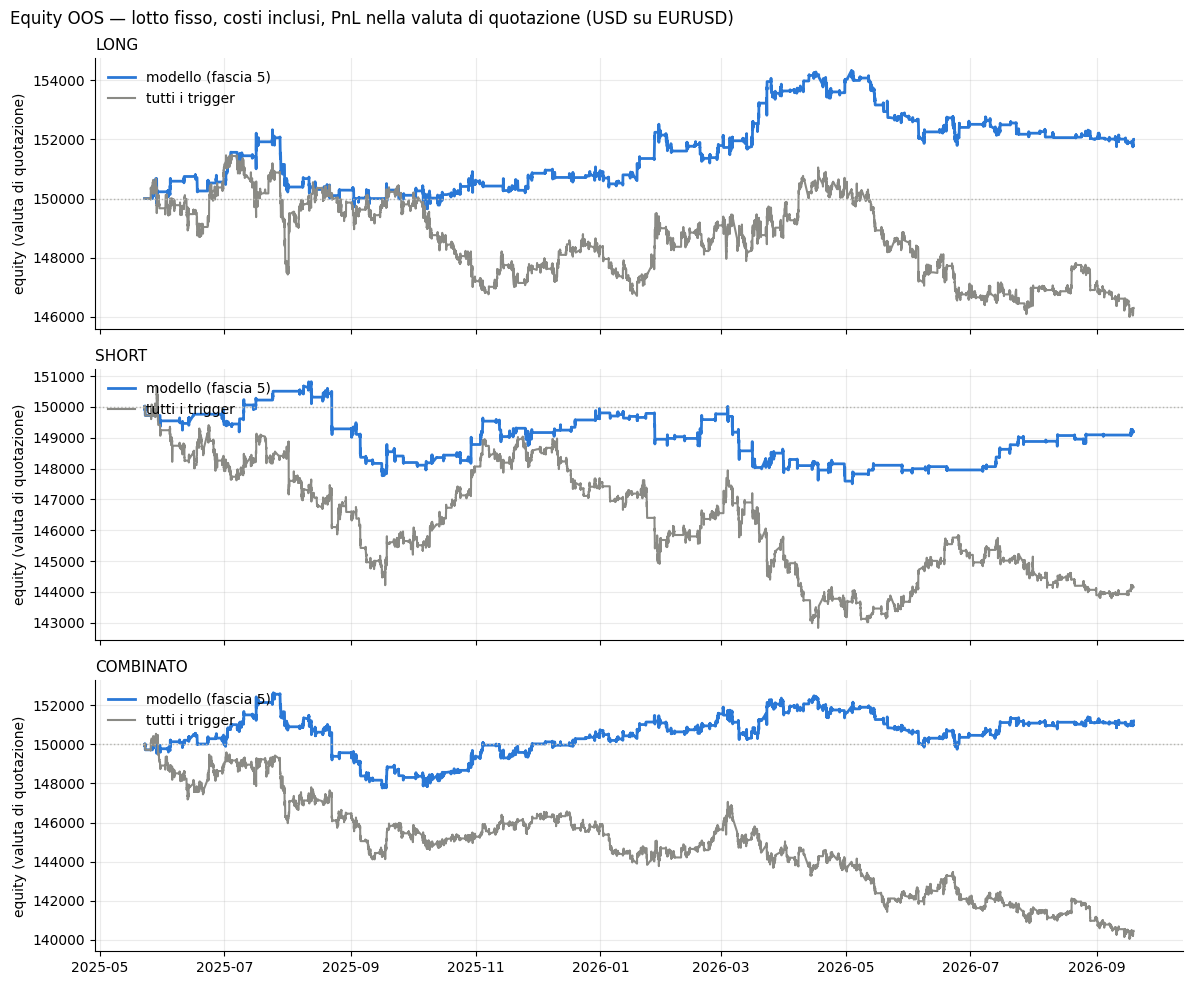

In [25]:
UNITA    = COSTI["lotto"]   # 1 lotto del symbol, dalla tabella costi
CAPITALE = 150_000          # deve coprire il controvalore di UNITA

df_periodo_oos = df.loc[df.index > df_is.index[-1]]

sel_L = trigger_in_fascia(modello_LONG_p, X_LONG, idx_test_L, idx_oos_L, fasce=FASCE_OPERATIVE)
sel_S = trigger_in_fascia(modello_SHORT_p, X_SHORT, idx_test_S, idx_oos_S, fasce=FASCE_OPERATIVE)

bt_modello = esegui_backtest(df_periodo_oos, sel_L, sel_S, H, unita=UNITA, capitale=CAPITALE,
                             costo_pips=COSTI["costo_pips"], pip_size=COSTI["pip_size"])
bt_tutti   = esegui_backtest(df_periodo_oos, idx_oos_L, idx_oos_S, H, unita=UNITA, capitale=CAPITALE,
                             costo_pips=COSTI["costo_pips"], pip_size=COSTI["pip_size"])

scenari = {f"modello (fascia {FASCE_OPERATIVE})": bt_modello, "tutti i trigger": bt_tutti}
print(tabella_metriche(scenari))
grafico_equity(scenari, CAPITALE);